In [2]:

from matplotlib import pyplot

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout, BatchNormalization, LeakyReLU, Activation
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Ways to Improve the Model:

1.  **Hyperparameter Tuning:**
    *   **Learning Rate:** Experiment with different learning rates for the optimizer (e.g., using a learning rate scheduler or trying values like 0.01, 0.001, 0.0001).
    *   **Batch Size:** Test different batch sizes (e.g., 32, 64, 128).
    *   **Number of Epochs:** Adjust the number of training epochs, perhaps letting Early Stopping determine the optimal point.
    *   **Optimizer:** While Adam is a good general-purpose optimizer, other optimizers like SGD with momentum, RMSprop, or Adagrad might perform better.

2.  **Model Architecture Improvements:**
    *   **Deeper or Wider Networks:** Experiment with adding more convolutional layers, increasing the number of filters per layer, or adding more dense layers.
    *   **Different Activation Functions:** Try other activation functions like ReLU (instead of ELU, though ELU is often good) in the hidden layers.
    *   **Different Kernel Sizes:** Experiment with different kernel sizes in the convolutional layers (e.g., smaller 3x3 kernels are often preferred).

3.  **Regularization Techniques:**
    *   **Dropout:** Experiment with different dropout rates or applying dropout in more layers.
    *   **L1/L2 Regularization:** Add L1 or L2 regularization to the convolutional or dense layers to prevent overfitting.

4.  **Data Augmentation:**
    *   The `ImageDataGenerator` is already used, but you could explore more aggressive augmentation techniques or custom augmentation pipelines.

5.  **Class Imbalance (if any):**
    *   Looking at `df['emotion'].value_counts()`, there is some imbalance (e.g., 'happy' has more samples than 'angry'). Techniques like class weighting, oversampling minority classes (SMOTE), or undersampling majority classes could be explored.

6.  **Transfer Learning:**
    *   For image tasks, using a pre-trained model (e.g., VGG, ResNet, Inception) on a large dataset like ImageNet and fine-tuning it for this specific task can often lead to significant performance improvements, especially with smaller datasets.

7.  **Ensemble Methods:**
    *   Training multiple models with different architectures or initializations and combining their predictions can often yield better results.

Which of these would you like to explore first?

In [3]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving fer2013_merged.csv to fer2013_merged.csv


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

# Define the path to your CSV file in Google Drive
# You might need to adjust this path based on where you save your file in Drive
csv_file_path = '/content/drive/MyDrive/fer2013_merged.csv'

# Check if the file exists before attempting to read it
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print(df.shape)
    display(df.head())
else:
    print(f"Error: The file '{csv_file_path}' was not found. Please ensure it's in your Google Drive at the specified path.")

(10424, 3)


,emotion,pixels,Usage
0,angry,46 34 26 23 12 32 35 26 26 38 71 99 123 134 14...,Training
1,angry,55 33 54 32 26 21 50 29 38 45 79 73 43 22 51 5...,Training
2,angry,123 123 126 131 124 69 109 149 159 174 169 178...,Training
3,angry,255 255 255 255 255 255 255 255 255 251 254 16...,Training
4,angry,127 121 124 137 123 118 120 111 111 109 118 14...,Training


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['fer2013_merged.csv']))
print(df.shape)
display(df.head())

(10424, 3)


,emotion,pixels,Usage
0,angry,46 34 26 23 12 32 35 26 26 38 71 99 123 134 14...,Training
1,angry,55 33 54 32 26 21 50 29 38 45 79 73 43 22 51 5...,Training
2,angry,123 123 126 131 124 69 109 149 159 174 169 178...,Training
3,angry,255 255 255 255 255 255 255 255 255 251 254 16...,Training
4,angry,127 121 124 137 123 118 120 111 111 109 118 14...,Training


In [8]:
df['emotion'].value_counts()

,count
emotion,
happy,3548
sad,2494
neutral,2466
angry,1916


In [9]:
emotion_label_to_text = {0:'anger', 1:'disgust', 2:'fear', 3:'happy', 4: 'sad', 5: 'surprise', 6: 'neutral'}

In [10]:
df['emotion'].unique()

array(['angry', 'happy', 'neutral', 'sad'], dtype=object)

In [11]:
print(df['pixels'].head())
print(df.shape)


0    46 34 26 23 12 32 35 26 26 38 71 99 123 134 14...
1    55 33 54 32 26 21 50 29 38 45 79 73 43 22 51 5...
2    123 123 126 131 124 69 109 149 159 174 169 178...
3    255 255 255 255 255 255 255 255 255 251 254 16...
4    127 121 124 137 123 118 120 111 111 109 118 14...
Name: pixels, dtype: object
(10424, 3)


In [12]:
img_array = df.pixels.apply(lambda x: np.array(x.split(' ')).reshape(48, 48, 1).astype('float32'))
img_array = img_array / 255.0

img_array = np.stack(img_array, axis=0)

In [13]:
df['emotion'].unique()

array(['angry', 'happy', 'neutral', 'sad'], dtype=object)

In [14]:
le = LabelEncoder()
img_labels = le.fit_transform(df['emotion'])
img_labels = to_categorical(img_labels)
img_labels.shape

(10424, 4)

In [15]:
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'angry': np.int64(0), 'happy': np.int64(1), 'neutral': np.int64(2), 'sad': np.int64(3)}


In [16]:
X_train, X_test, y_train, y_test = train_test_split(img_array, img_labels,
                                                    shuffle=True, stratify=img_labels,
                                                    test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8339, 48, 48, 1), (2085, 48, 48, 1), (8339, 4), (2085, 4))

In [17]:
img_width = X_train.shape[1]
img_height = X_train.shape[2]
img_depth = X_train.shape[3]
num_classes = y_train.shape[1]

In [18]:
X_train = X_train / 255.
X_test = X_test / 255.

In [31]:
def build_net(optim):
            net = Sequential(name='DCNN')

            net.add(Conv2D(filters=256,kernel_size=(5,5),input_shape=(img_width, img_height, img_depth),activation='relu',
                           padding='same',kernel_initializer='he_normal', name='conv2d_1'))
            net.add(BatchNormalization(name='batchnorm_1'))
            net.add(Conv2D(filters=128,kernel_size=(5,5),activation='elu',padding='same',kernel_initializer='he_normal',
                        name='conv2d_2'))
            net.add(BatchNormalization(name='batchnorm_2'))
            net.add(MaxPooling2D(pool_size=(2,2), name='maxpool2d_1'))
            net.add(Dropout(0.4, name='dropout_1'))
            net.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer='he_normal',
                        name='conv2d_3'))
            net.add(BatchNormalization(name='batchnorm_3'))
            net.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer='he_normal',
                        name='conv2d_4'))
            net.add(BatchNormalization(name='batchnorm_4'))
            net.add(MaxPooling2D(pool_size=(2,2), name='maxpool2d_2'))
            net.add(Dropout(0.4, name='dropout_2'))
            net.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer='he_normal',
                        name='conv2d_5'))
            net.add(BatchNormalization(name='batchnorm_5'))
            net.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same',kernel_initializer='he_normal',
                        name='conv2d_6'))
            net.add(BatchNormalization(name='batchnorm_6'))
            net.add(MaxPooling2D(pool_size=(2,2), name='maxpool2d_3'))
            net.add(Dropout(0.5, name='dropout_3'))
            net.add(Flatten(name='flatten'))
            net.add(Dense(128,activation='relu',kernel_initializer='he_normal',name='dense_1'))
            net.add(BatchNormalization(name='batchnorm_7'))
            net.add(Dropout(0.6, name='dropout_4'))
            net.add(Dense(num_classes,activation='softmax',name='out_layer'))

            net.compile(loss='categorical_crossentropy',metrics=['accuracy'])

            net.summary()

            return net



In [32]:

early_stopping = EarlyStopping(monitor='val_accuracy',min_delta=0.00005,patience=10,verbose=1,
    restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_accuracy',factor=0.5,patience=7,min_lr=1e-7,verbose=1)

callbacks = [early_stopping,lr_scheduler]

In [33]:
train_datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
train_datagen.fit(X_train)

In [34]:
batch_size = 32
epochs = 75
optims = [optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name='Nadam'),
          optimizers.Nadam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name='Nadam_lr_0.01'),
          optimizers.Nadam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, name='Nadam_lr_0.0001')
         ]

model = build_net(optims[1]) # Changed to optims[1] for Nadam with lr=0.0001
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=batch_size),validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // batch_size,epochs=epochs,callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 256)    │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_4                     │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_5                     │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_6                     │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_7                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,191,812 (12.18 MB)

 Trainable params: 3,189,252 (12.17 MB)

...

260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4062 - loss: 1.4599 - val_accuracy: 0.2633 - val_loss: 1.4163 - learning_rate: 0.0010
Epoch 3/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.2957 - loss: 1.6314 - val_accuracy: 0.2878 - val_loss: 1.4023 - learning_rate: 0.0010
Epoch 4/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2188 - loss: 1.5123 - val_accuracy: 0.3161 - val_loss: 1.3615 - learning_rate: 0.0010
Epoch 5/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.3131 - loss: 1.4388 - val_accuracy: 0.3626 - val_loss: 1.3302 - learning_rate: 0.0010
Epoch 6/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3125 - loss: 1.4419 - val_accuracy: 0.3693 - val_loss: 1.3278 - learning_rate: 0.0010
Epoch 7/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.3329 - loss: 1.3795 - val_accuracy: 0.3626 - val_loss: 1.3161 - learning_rate: 0.0010
Epoch 8/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3750 - loss: 1.2847 - val_a

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4375 - loss: 1.1175 - val_accuracy: 0.4657 - val_loss: 1.1950 - learning_rate: 0.0010
Epoch 21/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.4756 - loss: 1.1688 - val_accuracy: 0.4930 - val_loss: 1.1533 - learning_rate: 0.0010
Epoch 22/75
  1/260 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.5938 - loss: 1.0443

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5938 - loss: 1.0443 - val_accuracy: 0.5074 - val_loss: 1.1225 - learning_rate: 0.0010
Epoch 23/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4893 - loss: 1.1376 - val_accuracy: 0.4484 - val_loss: 1.2176 - learning_rate: 0.0010
Epoch 24/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6250 - loss: 1.0283 - val_accuracy: 0.4388 - val_loss: 1.2121 - learning_rate: 0.0010
Epoch 25/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.5085 - loss: 1.1005 - val_accuracy: 0.5022 - val_loss: 1.1521 - learning_rate: 0.0010
Epoch 26/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5625 - loss: 1.1438 - val_accuracy: 0.5055 - val_loss: 1.1695 - learning_rate: 0.0010
Epoch 27/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.5356 - loss: 1.0670 - val_accuracy: 0.5612 - val_loss: 1.0027 - learning_rate: 0.0010
Epoch 28/75
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4375 - loss: 1.3220 -

In [40]:
model.save("final_model3.h5")

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


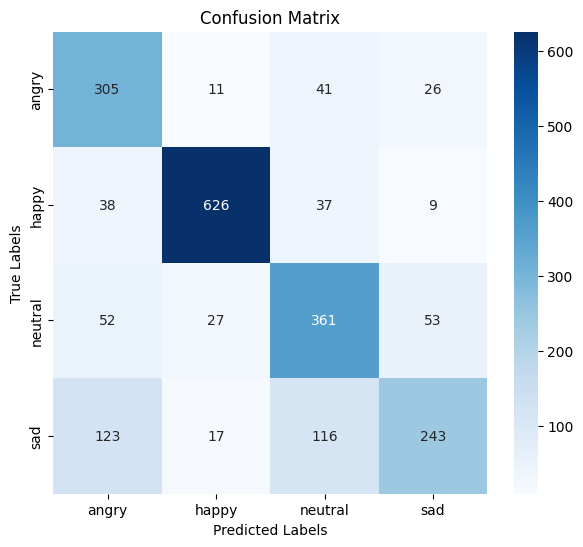


Classification Report:

              precision    recall  f1-score   support

       angry       0.59      0.80      0.68       383
       happy       0.92      0.88      0.90       710
     neutral       0.65      0.73      0.69       493
         sad       0.73      0.49      0.59       499

    accuracy                           0.74      2085
   macro avg       0.72      0.72      0.71      2085
weighted avg       0.75      0.74      0.73      2085



In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt


y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


class_labels = le.classes_.tolist()


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


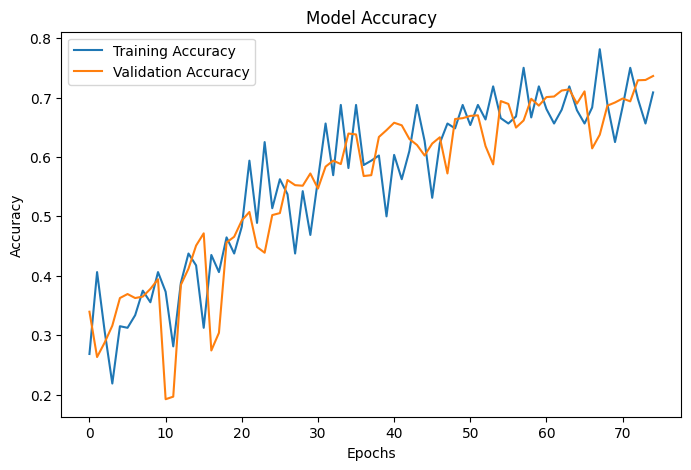

In [37]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


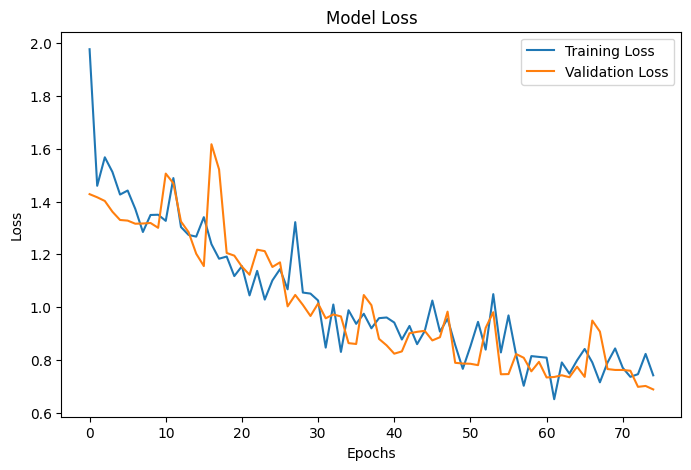

In [38]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred_classes, average='macro')  # 'macro' for unweighted mean
print("F1 Score:", f1)

F1 Score: 0.7128927210756819
